Neural Networks for Handwritten Digit Recognition, Binary

Creating data

In [16]:
import numpy as np
import tensorflow as tf

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

from tensorflow.keras.datasets import mnist
from tensorflow.image import resize
# 1. Load MNIST
(X_train, y_train), _ = mnist.load_data()

# 2. Filter only 0 and 1
mask = (y_train == 0) | (y_train == 1)
X = X_train[mask]
y = y_train[mask]

# 3. Take only 1000 samples
X = X[:1000]
y = y[:1000]

# 4. Resize 28x28 → 20x20
X_resized = resize(X[..., np.newaxis], (20,20)).numpy()

# 5. Flatten → 400 features
X_flat = X_resized.reshape(1000, 400)

# 6. Normalize (important)
X_flat = X_flat / 255.0

# 7. Reshape y → (1000,1)
y = y.reshape(-1,1)

print(X_flat.shape, y.shape)

(1000, 400) (1000, 1)


visualization

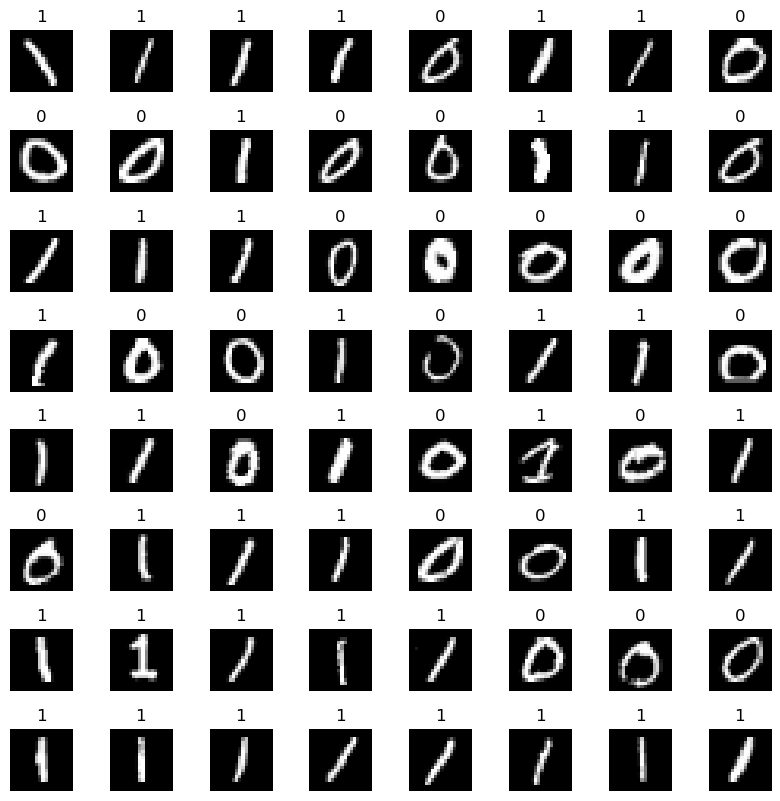

In [17]:
import numpy as np
import matplotlib.pyplot as plt

m = X_flat.shape[0] 
fig, axes = plt.subplots(8,8, figsize=(8,8))
plt.tight_layout(pad=0.1)

for i, ax in enumerate(axes.flat):
    random_index = np.random.randint(0,m)
    random_X_reshaped = X_flat[random_index].reshape((20,20))

    ax.imshow(random_X_reshaped, cmap="gray")
    ax.set_title(y[random_index,0])
    ax.set_axis_off()


model

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

model = Sequential([
    Input((400,)),
    Flatten(),
    Dense(25, activation="sigmoid"),
    Dense(15, activation="sigmoid"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
], name="model_layer")


In [19]:
model.summary()

Model: "model_layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,431 (40.75 KB)

 Trainable params: 10,431 (40.75 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from tensorflow.keras.losses import BinaryCrossentropy 
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.01),loss=BinaryCrossentropy(),metrics=["accuracy"])

In [30]:
from tensorflow.keras.layers import Normalization 
norm = Normalization(axis=-1)
norm.adapt(X_flat)
X_norm = norm(X_flat)

X_norm = np.tile(X_norm, (1000, 1))
y = np.tile(y, (1000,1))

In [31]:
model.fit(X_norm, y, epochs=20)

Epoch 1/20
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 23s 735us/step - accuracy: 1.0000 - loss: 6.1163e-05
Epoch 2/20
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 23s 734us/step - accuracy: 1.0000 - loss: 8.8121e-07
Epoch 3/20
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 22s 698us/step - accuracy: 1.0000 - loss: 4.3605e-07
Epoch 4/20
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 23s 726us/step - accuracy: 1.0000 - loss: 4.4131e-07
Epoch 5/20
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 22s 716us/step - accuracy: 1.0000 - loss: 7.3243e-06
Epoch 6/20
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 22s 707us/step - accuracy: 1.0000 - loss: 2.2988e-07
Epoch 7/20
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 22s 707us/step - accuracy: 1.0000 - loss: 1.3637e-05
Epoch 8/20
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 22s 715us/step - accuracy: 1.0000 - loss: 1.4836e-07
Epoch 9/20
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 22s 713us/step - accuracy: 1.0000 - loss: 8.7766e-08
Epoch 10/20
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 22s 713us/step - accuracy: 1.0000 - loss: 1.1181e-07
Epoch 11/20
31250/31250 ━━━━━

In [38]:
predict = model.predict(X_norm[10].reshape(1,-1))

print(int(predict >= 0.5))
print(y[10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1
[1]


C:\Users\Taiyob Ali\AppData\Local\Temp\ipykernel_23420\4170881832.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(int(predict >= 0.5))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━

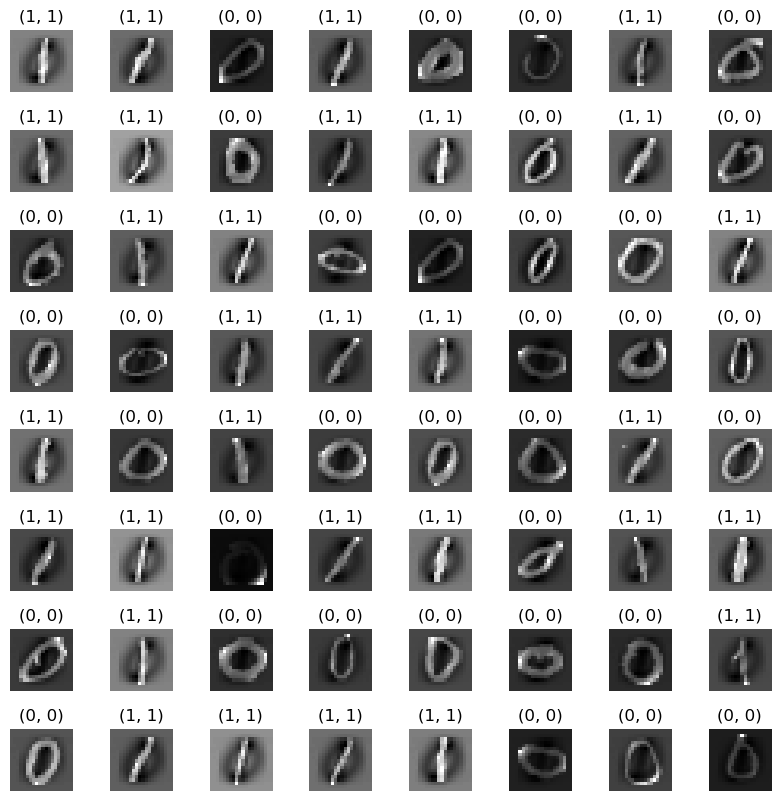

In [46]:
m = X_norm.shape[0]

fig, axes = plt.subplots(8,8,figsize=(8,8))
plt.tight_layout(pad=0.1)

for i, ax in enumerate(axes.flat):
    random_index = np.random.randint(0,m)
    random_X_reshaped = X_norm[random_index].reshape((20,20))

    ax.imshow(random_X_reshaped, cmap="gray")
    yhat = model.predict(X_norm[random_index].reshape(1,-1))
    y2 = (yhat >= 0.5).astype(int)
    ax.set_title(f"{y[random_index,0], y2[0,0]}")
    ax.set_axis_off()

In [47]:
yhat = model.predict(X_norm[random_index].reshape(1,-1))
y2 = (yhat >= 0.5).astype(int)
y2[0,0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


0